In [ ]:
# importing pandas as pd
import pandas as pd

# Creating the dataframe
df = pd.DataFrame({"A":[12, 4, 5, None, 1],
                   "B":[None, 2, 54, 3, None],
                   "C":[20, 16, None, 3, 8],
                   "D":[14, 3, None, None, 6]})


In [24]:
print("Dataset Shape (Rows, Columns):")
print(df.dtypes)


Dataset Shape (Rows, Columns):
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object


In [ ]:
#==============================================================
# Dataset Shape
#==============================================================
print("Dataset Shape (Rows, Columns):")
print(df.shape)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
print(df.dtypes)

#==============================================================
# Missing Values Per Column
#==============================================================

print("\nMissing Values Per Column:")
missing_count = df.isna().sum()
print(missing_count)

#==============================================================
# Missing Percentage Per Column
#==============================================================
print("\nMissing Percentage Per Column (%):")
missing_percentage = (df.isna().mean() * 100).round(2)
print(missing_percentage)

#==============================================================
# Columns That Have Missing Values Only
#==============================================================
print("\nColumns with Missing Values:")
print(missing_count[missing_count > 0])

#==============================================================
# Total Missing Values
#==============================================================
total_missing = df.isna().sum().sum()

print("\nTotal Missing Values in Dataset:")
print(total_missing)

#==============================================================
# Overall Missing Percentage
#==============================================================
total_cells = df.shape[0] * df.shape[1]
overall_missing_percentage = (total_missing / total_cells) * 100

print("\nOverall Missing Percentage:")
print(f"{overall_missing_percentage:.2f}%")

Dataset Shape (Rows, Columns):
(5, 4)

Number of Rows: 5
Number of Columns: 4
A    float64
B    float64
C    float64
D    float64
dtype: object

Missing Values Per Column:
A    1
B    2
C    1
D    2
dtype: int64

Missing Percentage Per Column (%):
A    20.0
B    40.0
C    20.0
D    40.0
dtype: float64

Columns with Missing Values:
A    1
B    2
C    1
D    2
dtype: int64

Total Missing Values in Dataset:
6

Overall Missing Percentage:
30.00%


In [16]:
print(df)

      A     B     C     D
0  12.0   NaN  20.0  14.0
1   4.0   2.0  16.0   3.0
2   5.0  54.0   NaN   NaN
3   NaN   3.0   3.0   NaN
4   1.0   NaN   8.0   6.0


In [17]:
# to interpolate the missing values
df.interpolate(method ='linear', limit_direction ='forward')

,A,B,C,D
0,12.0,NaN,20.0,14.0
1,4.0,2.0,16.0,3.0
2,5.0,54.0,9.5,4.0
3,3.0,3.0,3.0,5.0
4,1.0,3.0,8.0,6.0


In [18]:
import pandas as pd

# Creating the dataframe
df = pd.DataFrame({"A":[12, 4, 5, None, 1],
                   "B":[None, 2, 54, 3, None],
                   "C":[20, 16, None, 3, 8],
                   "D":[14, 3, None, None, 6]})

# to interpolate the missing values
df.interpolate(method ='linear', limit_direction ='backward', limit = 1)

,A,B,C,D
0,12.0,2.0,20.0,14.0
1,4.0,2.0,16.0,3.0
2,5.0,54.0,9.5,NaN
3,3.0,3.0,3.0,5.0
4,1.0,NaN,8.0,6.0


In [19]:
import pandas as pd

Mypath = "household_power_consumption.txt"
MyOutput = "MyData.csv"
#==============================================================
# Load the semicolon-separated dataset.
df = pd.read_csv(
    Mypath,
    sep=";",
    na_values="?",
    low_memory=False,
)
#==============================================================
# Combine the Date and Time strings.
datetime_text = df["Date"] + " " + df["Time"]
#==============================================================
# Convert the combined strings to datetime values.
df["Datetime"] = pd.to_datetime(
    datetime_text,
    format="%d/%m/%Y %H:%M:%S",
    errors="raise",
)
#==============================================================
# Remove the old columns and use Datetime as the time-series index.
df = (
    df.drop(columns=["Date", "Time"])
      .set_index("Datetime")
      .sort_index()
)
#==============================================================
# Save the cleaned dataset.
df.to_csv(MyOutput)

print("Final shape:", df.shape)
print("Index type:", type(df.index))
print("Missing values:", df.isna().sum().sum())
print("Saved to:", MyOutput)

display(df.head(3))

Final shape: (2075259, 7)
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Missing values: 181853
Saved to: MyData.csv


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0


In [ ]:
df.head(5)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [ ]:
#==============================================================
# Dataset Shape
#==============================================================
print("Dataset Shape (Rows, Columns):")
print(df.shape)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
print(df.dtypes)

#==============================================================
# Missing Values Per Column
#==============================================================

print("\nMissing Values Per Column:")
missing_count = df.isna().sum()
print(missing_count)

#==============================================================
# Missing Percentage Per Column
#==============================================================
print("\nMissing Percentage Per Column (%):")
missing_percentage = (df.isna().mean() * 100).round(2)
print(missing_percentage)

#==============================================================
# Columns That Have Missing Values Only
#==============================================================
print("\nColumns with Missing Values:")
print(missing_count[missing_count > 0])

#==============================================================
# Total Missing Values
#==============================================================
total_missing = df.isna().sum().sum()

print("\nTotal Missing Values in Dataset:")
print(total_missing)

#==============================================================
# Overall Missing Percentage
#==============================================================
total_cells = df.shape[0] * df.shape[1]
overall_missing_percentage = (total_missing / total_cells) * 100

print("\nOverall Missing Percentage:")
print(f"{overall_missing_percentage:.2f}%")

Dataset Shape (Rows, Columns):
(2075259, 7)

Number of Rows: 2075259
Number of Columns: 7
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

Missing Values Per Column:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Missing Percentage Per Column (%):
Global_active_power      1.25
Global_reactive_power    1.25
Voltage                  1.25
Global_intensity         1.25
Sub_metering_1           1.25
Sub_metering_2           1.25
Sub_metering_3           1.25
dtype: float64

Columns with Missing Values:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity       

**Why the values are missing** In this dataset, missingness comes from sensor/meter outages  when the meter went down, entire rows disappear at once (that's why every column has the same ~25,979 missing count, ≈1.25% of 2,075,259 rows). This matters because the data is "missing at random" with respect to time gaps, not corrupted individual readings. The gaps range from single minutes to a few multi-day outages.

**Choosing an imputation method. The right choice depends on the gap structure:**

**Forward-fill** repeats the last known value. Reasonable for very short gaps in slowly-changing signals (like voltage), but for multi-day gaps it produces a flat, unrealistic line and freezes the daily consumption cycle.
**Backward-fill** same idea in reverse; same weakness, plus it "leaks" future information backwards  a concern if you later do forecasting.
Linear interpolation: draws a straight line between the last and next known values. Good for short gaps (minutes to an hour) because power consumption is locally smooth. For long gaps it also flattens the daily pattern, but less abruptly than ffill.
** Time-aware ** for long gaps, a more defensible approach is filling with the value from the same time on the previous day or previous week, since household electricity has strong daily and weekly seasonality. This preserves the shape of the load curve.
**Dropping** with only 1.25% missing, simply dropping is also defensible for some analyses but it creates holes in the time index, which breaks resampling and sequence models.

A common, well-justified hybrid for this dataset: linear interpolation for short gaps , and same-time-previous-week fill for long gaps. Short gaps are smooth enough for interpolation; long outages are better patched with seasonally-matching values.

In [ ]:
# 2. Analyze the gaps
print("Missing per column:\n", df.isna().sum())
print(f"\nMissing fraction: {df['Global_active_power'].isna().mean():.3%}")

Missing per column:
 Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Missing fraction: 1.252%


In [20]:
# Find lengths of consecutive missing runs
is_na = df["Global_active_power"].isna()
print()
gap_id = (is_na != is_na.shift()).cumsum()
gap_lengths = is_na.groupby(gap_id).sum()
gap_lengths = gap_lengths[gap_lengths > 0]
print("\nGap length distribution (minutes):")
print(gap_lengths.describe())
print(f"Gaps ≤ 60 min: {(gap_lengths <= 60).sum()} "
      f"| Gaps > 60 min: {(gap_lengths > 60).sum()}")




Gap length distribution (minutes):
count      71.000000
mean      365.901408
std      1251.468043
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max      7226.000000
Name: Global_active_power, dtype: float64
Gaps ≤ 60 min: 62 | Gaps > 60 min: 9


In [21]:
# Find lengths of consecutive missing runs
is_na = df["Global_active_power"].isna()
print(len(is_na))
gap_id = (is_na != is_na.shift()).cumsum()
gap_lengths = is_na.groupby(gap_id).sum()
gap_lengths = gap_lengths[gap_lengths > 0]
print("\nGap length distribution (minutes):")
print(gap_lengths.describe())
print(f"Gaps ≤ 60 min: {(gap_lengths <= 60).sum()} "
      f"| Gaps > 60 min: {(gap_lengths > 60).sum()}")


2075259

Gap length distribution (minutes):
count      71.000000
mean      365.901408
std      1251.468043
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max      7226.000000
Name: Global_active_power, dtype: float64
Gaps ≤ 60 min: 62 | Gaps > 60 min: 9



Remaining missing after short-gap interpolation: 24698
All missing values imputed.

Hourly dataset: (34589, 8)


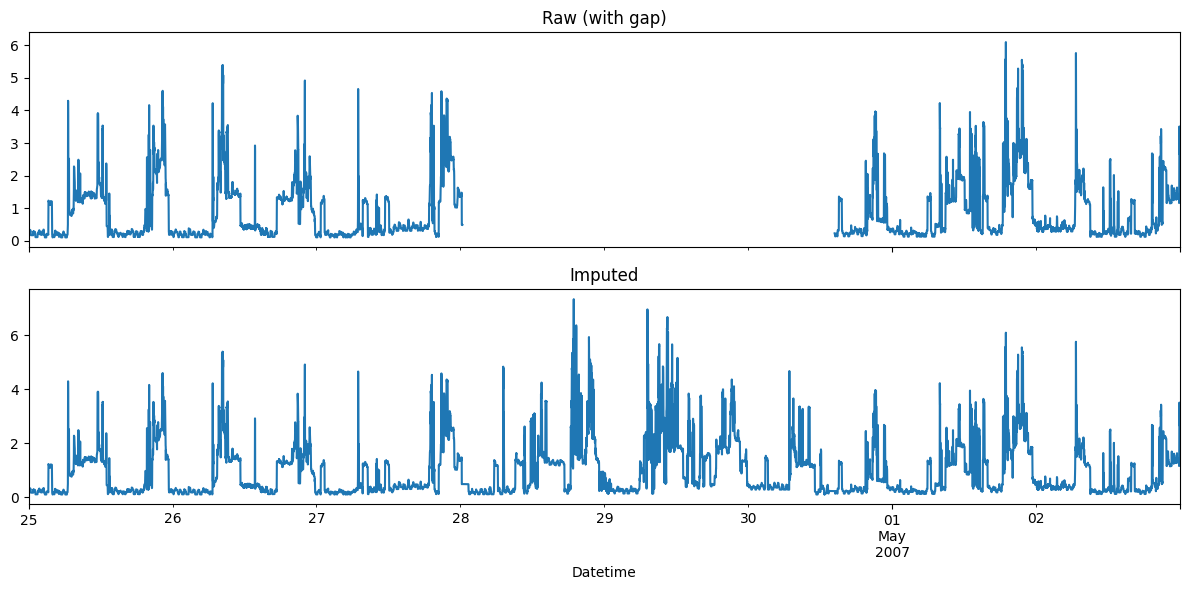

In [22]:
df1 = df.interpolate(method="time", limit=60, limit_direction="both")

# Remaining NaNs are the long outages same-time-last-week fill
still_missing = df1["Global_active_power"].isna()
print(f"\nRemaining missing after short-gap interpolation: {still_missing.sum()}")

week = pd.Timedelta(days=7)
shifted = df1.shift(freq=week)          # values from 7 days earlier
df_imputed = df1.fillna(shifted)

# Rare edge case: a long gap whose previous week was also missing
df_imputed = df_imputed.fillna(df_imputed.shift(freq=2 * week))
df_imputed = df_imputed.interpolate(method="time")   # final safety net

assert df_imputed.isna().sum().sum() == 0, "Unresolved missing values remain"
print("All missing values imputed.")

# ── 4. Resample minute data to hourly aggregates ─────────────────
# mean  → power/voltage/intensity (avg power ∝ energy used, robust)
# sum   → sub-metering (Wh per minute summed = Wh per hour, physical energy)
# max   → optional peak-demand feature
hourly = df_imputed.resample("h").agg({
    "Global_active_power":   "mean",
    "Global_reactive_power": "mean",
    "Voltage":               "mean",
    "Global_intensity":      "mean",
    "Sub_metering_1":        "sum",
    "Sub_metering_2":        "sum",
    "Sub_metering_3":        "sum",
})
hourly["Peak_active_power"] = (
    df_imputed["Global_active_power"].resample("h").max()
)

print("\nHourly dataset:", hourly.shape)
hourly.head()

# ── 5. Sanity-check visualization (before/after around a known outage) ──
import matplotlib.pyplot as plt

window = slice("2007-04-25", "2007-05-02")   # covers the big April 2007 gap
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
df["Global_active_power"][window].plot(ax=ax[0], title="Raw (with gap)")
df_imputed["Global_active_power"][window].plot(ax=ax[1], title="Imputed")
plt.tight_layout()
plt.show()